In [1]:
# A set of functions to construct pulses for QoC
# Specifically Wurst pulses
include("operator_terms.jl")
include("combinatorics.jl")
include("cumulants.jl")
include("diff_Eq.jl")
include("preprocessing.jl")
include("indexing.jl")
include("diff_Eq_solver.jl")
using Plots

In [2]:
function basis_wurst_pulse_value(t::Float64, T::Float64, n::Int, Lambda::Float64, phi0::Float64=0.0)::ComplexF64
    phi::Float64 = Lambda*(t-t^2/T)*4*pi + phi0	
    val::ComplexF64 = (1- abs(sin(pi*(t-T/2)/T))^n)*exp(im*phi)
    return val
end
function basis_wurst_pulse_values(t::Vector{Float64}, T::Float64, n::Int, Lambda::Float64, phi0::Float64=0.0)::Vector{ComplexF64}
    # Vector of values
    vals::Vector{ComplexF64} = basis_wurst_pulse_value.(t, T, n, Lambda, phi0)
    return vals
end

function fourier_from_pulse_values(vals::Union{Vector{Float64}, Vector{ComplexF64}}, t::Vector{Float64}, omegas::Vector{Float64})::Vector{ComplexF64}
    # For every omega in omegas compute the fourier coefficient
    coeffs::Vector{ComplexF64} = Vector{ComplexF64}(undef, length(omegas))
    for (i, omega) in enumerate(omegas)
        coeffs[i] = sum(vals .* exp.(-im * omega * t))
    end
    return coeffs
end

fourier_from_pulse_values (generic function with 1 method)

In [44]:
# Generators and Parameters
mutable struct Pulse_Param_Struct
    Amplitudes::Vector{Float64}
    omegas::Vector{Float64}
    phi0::Float64
    T::Float64
    n::Int
    # initialize with default values
    function Pulse_Param_Struct(; Amplitudes::Vector{Float64}=[1.0], omegas::Vector{Float64}=[1.0], phi0::Float64=0.0, T::Float64=1.0, n::Int=10)
        new(Amplitudes, omegas, phi0, T, n)
    end
end

function wurst_pulse_generator(pulse_params::Pulse_Param_Struct)::Function
    # Generate a Wurst pulse generating function from the parameters
    pp = pulse_params
    function fun(t::Float64)
        if t < 0 || t > pp.T
            return 0.0+0.0im
        end
        val::ComplexF64 = pp.Amplitudes[1]*basis_wurst_pulse_value(t, pp.T, pp.n, pp.omegas[1], pp.phi0)
        for i in 2:length(pp.Amplitudes)
            val += pp.Amplitudes[i]*basis_wurst_pulse_value(t, pp.T, pp.n, pp.omegas[i], pp.phi0)
        end
        return val
    end
    return fun
end
# Test
pulse_param = Pulse_Param_Struct(Amplitudes=[1.0], omegas=[1.0])
wurst_fun = wurst_pulse_generator(pulse_param)
wurst_fun(0.5)

-1.0 + 1.2246467991473532e-16im

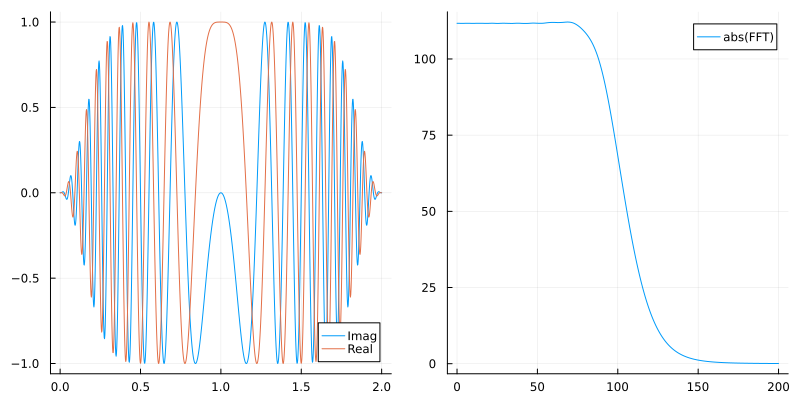

In [45]:

# plot a WURST pulse and its fourier transform
# initialize two subplots next to one another
plts = plot(layout=(1,2), size=(800, 400))
T = 2.0
n = 20
t::Vector{Float64} = range(0, stop=T, length=1000)
Lambda = 10.0
vals = basis_wurst_pulse_values(t, T, n, Lambda)
plot!(plts[1], t, imag.(vals), label="Imag")
plot!(plts[1], t, real.(vals), label="Real")
# Plot the fourier transform in the second plot
omegas::Vector{Float64} = range(0, stop=200, length=1000)
coeffs = fourier_from_pulse_values(vals, t, omegas)
plot!(plts[2], omegas, abs.(coeffs), label="abs(FFT)")
display(plts)

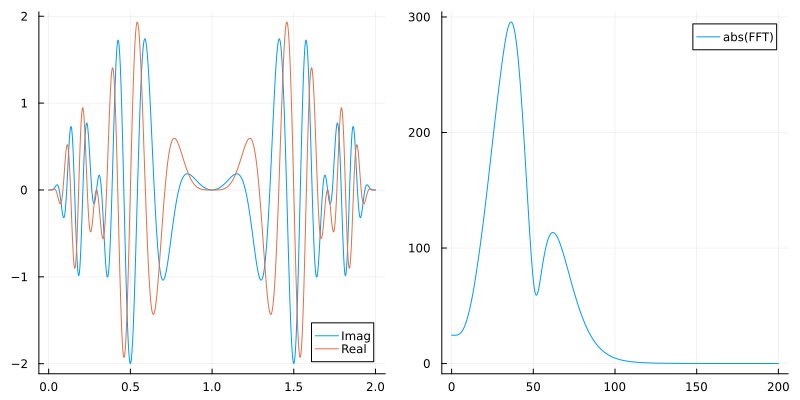

In [46]:
# Superposition of two WURST pulses and the corresponding Fourier transform
# initialize two subplots next to one another
plts = plot(layout=(1,2), size=(800, 400))
T = 2.0
n = 20
t::Vector{Float64} = range(0, stop=T, length=1000)
Lambdas = [5.0,7.0]
vals1 = basis_wurst_pulse_values(t, T, n, Lambdas[1])
vals2 = basis_wurst_pulse_values(t, T, n, Lambdas[2])
c1 = 1.0
c2 = -1.0
vals = c1*vals1 + c2*vals2
plot!(plts[1], t, imag.(vals), label="Imag")
plot!(plts[1], t, real.(vals), label="Real")
# Plot the fourier transform in the second plot
omegas::Vector{Float64} = range(0, stop=200, length=1000)
coeffs = fourier_from_pulse_values(vals, t, omegas)
plot!(plts[2], omegas, abs.(coeffs), label="abs(FFT)")
display(plts)

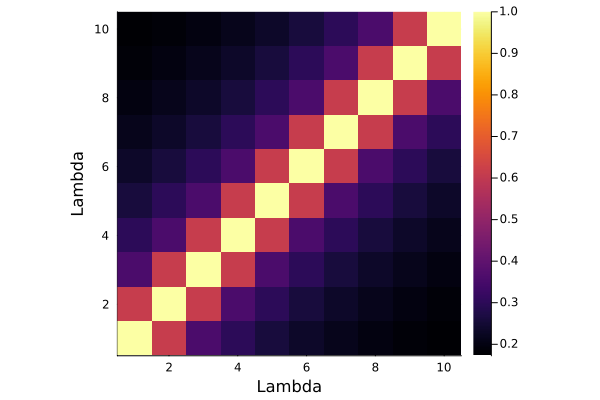

In [47]:
# how orthogonal are the WURST Pulses with different Lambdas 
using LinearAlgebra
how_many = 10
Lambdas = range(1, stop=how_many, length=how_many)
T = 2.0
n = 10
t::Vector{Float64} = range(0, stop=T, length=1000)
all_vals::Matrix{ComplexF64} = zeros(ComplexF64, length(t), how_many) # julia stores matrices in column major order (i.e. column by column unlike python, but like fortran)
for (i, Lambda) in enumerate(Lambdas)
    vals = basis_wurst_pulse_values(t, T, n, Lambda)
    all_vals[:,i] = vals/norm(vals)
end
# Compute the dot products of every compination
dot_amplitudes::Matrix{Float64} = zeros(Float64, how_many, how_many)
for i in 1:how_many
    for j in i:how_many
        # vector product in julia is given by the dot function, available via the LinearAlgebra package
        dot_amplitudes[i,j] = abs(dot(all_vals[:,i], all_vals[:,j]))
        dot_amplitudes[j,i] = dot_amplitudes[i,j]
    end
end
# Plot the dot products matrix as a heatmap
heatmap(Lambdas, Lambdas, dot_amplitudes, aspect_ratio=:equal, xlabel="Lambda", ylabel="Lambda")
# make plot tight
plot!(xlims=(0.5, how_many+0.5), ylims=(0.5, how_many+0.5))


In [48]:
#### Generate Pulse Values

In [49]:
function num_args(f::Function)
    mthds = methods(f)
    for m in mthds
        sig = m.sig
        return length(sig.parameters)-1
    end
end

num_args (generic function with 1 method)

In [50]:
function value_generator(pulse_param::Pulse_Param_Struct, val_dict::Dict{String, Union{Float64, ComplexF64, Function}}, vars_vec::Vector{Vector{String}}, T::Float64=1.0)::Function
    # Generates a generator function that constructs values of the variables (as Vector{ComplexF64}) at a given time t
    # vars_vec is --> inverse_vars_vec of preprocess_index_inversion function
    # user just needs to call generator with the time t 
    # returns a function that takes a time t and returns a vector of values
    values::Vector{ComplexF64} = ones(ComplexF64, length(vars_vec))
    curr_values::Vector{ComplexF64} = ones(ComplexF64, length(vars_vec))
    # store where function handles are, the value of those indexes without the function and the indexes to which they apply
    func_handles::Vector{Function} = Function[]
    func_args::Vector{Bool} = Bool[]
    func_handle_indexes::Vector{Int} = Int[]
    index_conjugations::Vector{Bool} = Bool[]
    index_sqrt::Vector{Bool} = Bool[]
    do_conj::Bool = false
    do_sqrt::Bool = false
    # Start constructing
    for (i, vars) in enumerate(vars_vec)
        # get values from dictionary
        for j in 1:length(vars)
            curr_var = vars[j]
            # Determine if conjugate
            do_conj = false
            if occursin("^{*}", curr_var)
                do_conj = true
                curr_var = curr_var[1:end-4]
            end
            if occursin("\\sqrt{", curr_var)
                do_sqrt = true
                curr_var = curr_var[7:end-1]
            end

            # Determine if function handle
            curr_val = val_dict[curr_var]
            if typeof(curr_val) <: Function
                # store function handle
                push!(func_handles, curr_val)
                push!(func_handle_indexes, i)
                push!(index_conjugations, do_conj)
                push!(index_sqrt, do_sqrt)
                if num_args(curr_val) == 1
                    push!(func_args, false)
                else
                    push!(func_args, true) # pass more arguments
                end
            else
                if do_sqrt
                    curr_val = sqrt(curr_val)
                end
                if do_conj
                    curr_val = conj(curr_val)
                end
                values[i] *= curr_val
            end
        end
    end
    # Construct the generator function
    function generator(t::Float64)::Vector{ComplexF64}
        # update values
        if t > T
            error("t > T")
        end
        # take values and copy to curr_values
        curr_values = copy(values)
        curr_val::ComplexF64 = 0.0
        # update function handles
        for (fun, args, ind, do_conj, do_sqrt) in zip(func_handles, func_args, func_handle_indexes, index_conjugations, index_sqrt)
            if !args
                curr_val = fun(t)
            else
                curr_val = fun(t, pulse_param)
            end
            if do_sqrt
                curr_val = sqrt(curr_val)
            end
            if do_conj 
                curr_val = conj(curr_val)
            end
            curr_values[ind] *= curr_val
        end
        return curr_values
    end
    return generator
end
# Test
all_eqs = single_spin_gen_DE_up_to_order(2)
conjugate_to_basis!(all_eqs)
all_eqs_indexed, op_index_dicts, vars_dict, cumulant_terms_dict = parse_DE_to_indexes(all_eqs)
inverse_op_index_vec, inverse_vars_vec, inverse_cumulant_terms_vec = preprocess_index_inversion(op_index_dicts, vars_dict, cumulant_terms_dict)
T = 10.0
pulse_param = Pulse_Param_Struct(Amplitudes=[1.0], omegas=[1.0], T=T)
wurst_fun = wurst_pulse_generator(pulse_param)
val_dict::Dict{String, Union{ComplexF64, Float64, Function}} = Dict("g" => 0.5, "\\gamma" => 1.0, "\\Gamma" => 2.0, "\\kappa" => 2.0 , "\\Delta" => 1.4, "\\beta" => wurst_fun)
generator = value_generator(pulse_param, val_dict, inverse_vars_vec, T)
generator(0.0)

7-element Vector{ComplexF64}:
                0.5 + 0.0im
                0.0 + 0.0im
 1.4142135623730951 + 0.0im
 1.1832159566199232 + 0.0im
                1.0 + 0.0im
 1.4142135623730951 + 0.0im
                0.0 + 0.0im